# Heat-Sink Mass, Cost and Manufacturability Analysis

This notebook extends the thermal study into a multi-objective engineering comparison. The three heat-sink geometries are evaluated using their actual dimensions, material density, calculated solid volume, mass, raw-material cost and manufacturability.

**Geometry definitions**

| Design | Base | Fins | Fin dimensions |
|---|---|---:|---|
| Original | 80 × 50 × 5 mm | 8 | 5.5 × 50 × 50 mm |
| Geometry 1 | 60 × 50 × 5 mm | 6 | 5.5 × 50 × 50 mm |
| Geometry 2 | 40 × 50 × 5 mm | 4 | 5.5 × 50 × 50 mm |

The calculation assumes the fins are rectangular solids placed on top of the base, so fin and base volumes do not overlap.

**Repository note:** This file is the consolidated materials-analysis notebook retained for the final repository.


**Material-property traceability:** aluminium density 2.70 g/cm³ is supported by Hydro 6061-T6 data; the thermal model uses 170 W/mK as a rounded engineering value close to Hydro's typical ~167 W/mK. C11000 density 8.91 g/cm³ is taken from Copper Development Association grade data. Full source details are in `../docs/sources.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dimensions (mm)
fin_width_mm = 5.5
fin_height_mm = 50
fin_length_mm = 50
base_width_mm = 50
base_thickness_mm = 5

geometries = {
    "Original": {"base_length_mm": 80, "n_fins": 8},
    "Geometry 1": {"base_length_mm": 60, "n_fins": 6},
    "Geometry 2": {"base_length_mm": 40, "n_fins": 4},
}

# July 2026 benchmark prices
USD_PER_GBP = 1.3379

materials = {
    "Aluminium 6061-T6": {"density_g_cm3": 2.70, "raw_price_gbp_kg": 2.362657896704},
    "Copper C11000": {"density_g_cm3": 8.91, "raw_price_gbp_kg": 10.122580162942},
}

fin_volume_mm3 = fin_width_mm * fin_height_mm * fin_length_mm
rows = []
for geometry, g in geometries.items():
    base_volume_mm3 = g["base_length_mm"] * base_width_mm * base_thickness_mm
    total_volume_cm3 = (base_volume_mm3 + g["n_fins"] * fin_volume_mm3) / 1000
    for material, m in materials.items():
        mass_kg = total_volume_cm3 * m["density_g_cm3"] / 1000
        rows.append({
            "Geometry": geometry,
            "Material": material,
            "Volume (cm³)": total_volume_cm3,
            "Mass (kg)": mass_kg,
            "Raw material cost (GBP)": mass_kg * m["raw_price_gbp_kg"],
        })

mass_results = pd.DataFrame(rows)
mass_results.round(3)


,Geometry,Material,Volume (cm³),Mass (kg),Raw material cost (GBP)
0,Original,Aluminium 6061-T6,130.0,0.351,0.829
1,Original,Copper C11000,130.0,1.158,11.725
2,Geometry 1,Aluminium 6061-T6,97.5,0.263,0.622
3,Geometry 1,Copper C11000,97.5,0.869,8.794
4,Geometry 2,Aluminium 6061-T6,65.0,0.176,0.415
5,Geometry 2,Copper C11000,65.0,0.579,5.862


## Volume and Mass Results

The total volumes are **130 cm³** (Original), **97.5 cm³** (Geometry 1), and **65 cm³** (Geometry 2). This means Geometry 1 uses **25% less material** than the original, while Geometry 2 uses **50% less**.

For the same geometry, copper is approximately **3.30× heavier** than aluminium because of its higher density. The original aluminium heat sink is about **0.351 kg**, while the equivalent copper design is about **1.158 kg**.


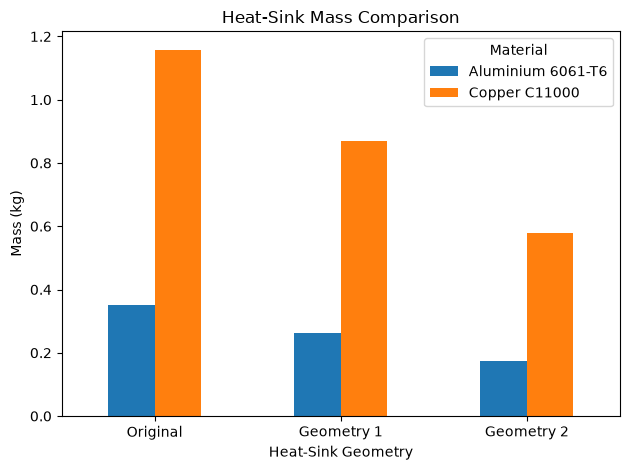

In [2]:
mass_plot = mass_results.pivot(index="Geometry", columns="Material", values="Mass (kg)").reindex(["Original", "Geometry 1", "Geometry 2"])
mass_plot.plot(kind="bar")
plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Mass (kg)")
plt.title("Heat-Sink Mass Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Raw-Material Cost Estimate

The material-only estimate uses **cost = mass × benchmark price per kg**. World Bank July 2026 monthly-average commodity prices are **US$3,161/metric tonne aluminium** and **US$13,543/metric tonne copper**. The Bank of England July 2026 monthly-average exchange rate is **£1 = US$1.3379**.

The resulting benchmark values used here are **£2.363/kg aluminium** and **£10.123/kg copper**. These are raw-material comparison values, not supplier quotations.

Finished heat-sink cost would additionally include extrusion or machining, tooling, cutting, surface finishing, labour, scrap, transport, supplier margin and order quantity. Therefore the values below must **not** be presented as manufacturing quotations.


### Cost Calculation Method

Raw-material cost was estimated using:

**Cost = Heat-sink mass × Material price per kg**

The heat-sink mass was calculated from the geometry volume and material density. This mass was then multiplied by a benchmark raw-material price for aluminium and copper.

The estimated cost represents **raw-material cost only** and does not include manufacturing expenses such as extrusion, machining, surface finishing, labour, tooling, scrap, transport, or supplier margin.

Copper has a substantially higher material-cost penalty because it is both more expensive per kilogram and approximately **3.30 times denser than aluminium** for the same heat-sink geometry.


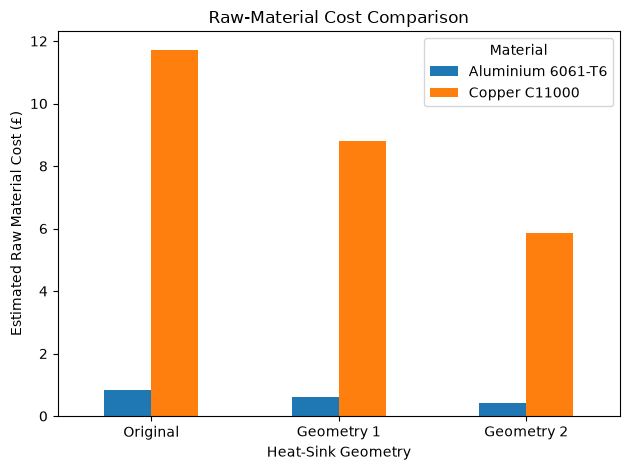

In [3]:
cost_plot = mass_results.pivot(index="Geometry", columns="Material", values="Raw material cost (GBP)").reindex(["Original", "Geometry 1", "Geometry 2"])
cost_plot.plot(kind="bar")
plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Estimated Raw Material Cost (£)")
plt.title("Raw-Material Cost Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Manufacturability and Industrial Use

### Aluminium 6061-T6
Aluminium is the stronger baseline manufacturing choice for this project. 6xxx-series aluminium is widely used for extrusion, and 6061 can also be machined after extrusion. The straight-fin form is compatible with an extrusion-led manufacturing route, followed by cutting, machining of mounting/contact features, finishing if required, and assembly.

The three investigated candidates are **not one identical extrusion cross-section cut to different lengths**. The 80 / 60 / 40 mm dimension is the dimension across which the fins are distributed, and the fin count changes 8 / 6 / 4. Changing this dimension therefore changes the cross-section. A production design may require its own extrusion die/profile or secondary machining/trimming of suitable stock.

For low-volume prototypes, machining or trimming standard material can avoid custom-die cost. At high production volume, a dedicated extrusion die for the selected geometry becomes more defensible. The lower mass of the selected 60 mm aluminium design also reduces material use, handling and mounting burden.

### Copper C11000
Copper provides higher thermal conductivity, but the same geometry is about 3.30× heavier. It also carries a much larger benchmark raw-material cost. For this design, the modest thermal benefit does not compensate for the mass and cost penalties unless additional thermal margin is particularly valuable.


### Manufacturability Comparison

| Factor | Aluminium 6061-T6 | Copper C11000 |
|---|---|---|
| Thermal conductivity | Moderate | High |
| Density | Low | High |
| Heat-sink mass | Lower | Much higher |
| Raw-material cost | Lower | Higher |
| Extrusion suitability | Very good | More limited / more costly |
| Machinability | Good | Good, but heavier to handle |
| Industrial integration | Easier | More demanding |
| Best use case | General heat-sink applications | High heat-flux / space-constrained applications |


## Thermal-Mass Trade-Off and Constraint

The controlled **1.505 W fixed heat-load** comparison must use the same heat input for all three geometries. The original 80 mm fixed-load value is therefore **32.885°C**, rather than the 33.108°C coupled 10 A value.

| Aluminium design | Mass | Tj at 1.505 W fixed load | Tj at 15 W | Margin to 125°C at 15 W | Raw-material cost |
|---|---:|---:|---:|---:|---:|
| Original 80 mm | 0.351 kg | 32.885°C | 103.595°C | +21.405°C | £0.829 |
| **Geometry 1 60 mm** | **0.263 kg** | **33.713°C** | **111.831°C** | **+13.169°C** | **£0.622** |
| Geometry 2 40 mm | 0.176 kg | 35.475°C | 129.400°C | -4.400°C | £0.415 |

At the fixed baseline load, reducing the heat sink from 80 mm to 60 mm removes **25% of the mass for only about 0.83°C temperature penalty**. At 15 W, the 40 mm geometry violates the 125°C project target.

The final geometry selection is therefore treated as a **discrete constrained optimisation**: minimise heat-sink mass among the tested aluminium candidates subject to **Tj ≤ 125°C at 15 W and 25°C ambient**.


In [4]:
# Export a reproducible summary used elsewhere in the repository
summary_rows = []
for geometry, g in geometries.items():
    row = {
        "Geometry": geometry,
        "Base_Length_mm": g["base_length_mm"],
        "Base_Width_mm": base_width_mm,
        "Base_Thickness_mm": base_thickness_mm,
        "Number_of_Fins": g["n_fins"],
        "Fin_Dimensions_mm": "5.5x50x50",
    }

    total_volume_cm3 = mass_results.loc[
        mass_results["Geometry"] == geometry, "Volume (cm³)"
    ].iloc[0]
    row["Total_Volume_cm3"] = total_volume_cm3

    for material, prefix in [("Aluminium 6061-T6", "Aluminium"), ("Copper C11000", "Copper")]:
        result = mass_results[(mass_results["Geometry"] == geometry) & (mass_results["Material"] == material)].iloc[0]
        row[f"{prefix}_Mass_kg"] = result["Mass (kg)"]
        row[f"{prefix}_Raw_Material_Cost_GBP"] = result["Raw material cost (GBP)"]

    row["Mass_Reduction_vs_Original_pct"] = {"Original": 0, "Geometry 1": 25, "Geometry 2": 50}[geometry]
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary_export = summary.round({
    "Total_Volume_cm3": 3,
    "Aluminium_Mass_kg": 6,
    "Copper_Mass_kg": 6,
    "Aluminium_Raw_Material_Cost_GBP": 6,
    "Copper_Raw_Material_Cost_GBP": 6,
})
summary_export.to_csv("../data/heatsink_mass_comparison.csv", index=False)
summary_export.round(3)


,Geometry,Base_Length_mm,Base_Width_mm,Base_Thickness_mm,Number_of_Fins,Fin_Dimensions_mm,Total_Volume_cm3,Aluminium_Mass_kg,Aluminium_Raw_Material_Cost_GBP,Copper_Mass_kg,Copper_Raw_Material_Cost_GBP,Mass_Reduction_vs_Original_pct
0,Original,80,50,5,8,5.5x50x50,130.0,0.351,0.829,1.158,11.725,0
1,Geometry 1,60,50,5,6,5.5x50x50,97.5,0.263,0.622,0.869,8.794,25
2,Geometry 2,40,50,5,4,5.5x50x50,65.0,0.176,0.415,0.579,5.862,50


## Recommendation from the Material / Geometry Screening

**Material screening:** Aluminium 6061-T6 is selected as the default material. Copper provides a small thermal improvement, but the equal-geometry mass penalty is about 3.30× and the benchmark raw-material cost is substantially higher.

**Geometry optimisation:** Among the tested aluminium candidates, **Geometry 1 (60 mm / 6 fins)** is the minimum-mass design that satisfies the project constraint of **Tj ≤ 125°C at 15 W**. The 80 mm design also passes but uses more material; the 40 mm design is lighter but fails the thermal requirement.

The recommendation is therefore **60 mm aluminium with the fixed TGP5000 interface**, conditional on the stated natural-convection assumptions.
